## Food data


In [3]:
import Pkg; Pkg.add("CSV"); Pkg.add("DataFrames")
using CSV
using DataFrames
using Statistics


   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/CODE/OpenDleto/Project.toml`
    Manifest No packages added to or removed from `~/CODE/OpenDleto/Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/CODE/OpenDleto/Project.toml`
    Manifest No packages added to or removed from `~/CODE/OpenDleto/Manifest.toml`


In [4]:
# Load all the CSV files
food_dir = "/Users/algeboy/CODE/OpenDleto/data/FoodData"

food = CSV.read(joinpath(food_dir, "food.csv"), DataFrame)
food_nutrient = CSV.read(joinpath(food_dir, "food_nutrient.csv"), DataFrame)
food_category = CSV.read(joinpath(food_dir, "food_category.csv"), DataFrame)
nutrient = CSV.read(joinpath(food_dir, "nutrient.csv"), DataFrame)

println("Loaded data:")
println("  food: ", size(food))
println("  food_nutrient: ", size(food_nutrient))
println("  food_category: ", size(food_category))
println("  nutrient: ", size(nutrient))

Loaded data:
  food: (78026, 5)
  food_nutrient: (159285, 11)
  food_category: (28, 3)
  nutrient: (477, 5)


In [5]:
# Pivot nutrients to wide format (one column per nutrient)
# This combines multiple nutrient rows for each food ID into one row

# Join nutrient names
nutrient_with_names = leftjoin(food_nutrient, nutrient, on = :nutrient_id => :id, makeunique=true)

# Create a column with nutrient_name for pivoting
nutrient_with_names[!, :nutrient_col] = coalesce.(nutrient_with_names.name, "Unknown")

# Pivot: each nutrient becomes a column
# Use combine=mean to handle duplicate entries (average them)
pivoted = unstack(nutrient_with_names, :fdc_id, :nutrient_col, :amount, 
                  allowmissing=true, combine=mean)

println("Pivoted nutrients: ", size(pivoted))
first(pivoted, 3)

Pivoted nutrients: (66451, 228)


Row,fdc_id,Water,Nitrogen,Total lipid (fat),Ash,"Phosphorus, P","Manganese, Mn","Potassium, K","Calcium, Ca","Sodium, Na","Magnesium, Mg","Iron, Fe","Copper, Cu","Zinc, Zn",Pantothenic acid,SFA 14:0,SFA 24:0,SFA 11:0,SFA 18:0,PUFA 22:6 n-3 (DHA),SFA 6:0,PUFA 22:4,SFA 15:0,PUFA 20:5 n-3 (EPA),PUFA 18:2 CLAs,PUFA 20:4,SFA 4:0,SFA 16:0,TFA 16:1 t,PUFA 18:4,SFA 22:0,PUFA 22:5 n-3 (DPA),TFA 18:1 t,PUFA 20:3 n-9,MUFA 15:1,MUFA 18:1 c,MUFA 20:1 c,"PUFA 18:3 n-3 c,c,c (ALA)",SFA 20:0,TFA 22:1 t,PUFA 22:2,"PUFA 20:2 n-6 c,c",MUFA 22:1 n-9,SFA 10:0,SFA 17:0,SFA 12:0,SFA 8:0,TFA 18:2 t not further defined,MUFA 16:1 c,PUFA 20:3 n-6,TFA 18:3 t,"PUFA 18:3 n-6 c,c,c","PUFA 18:2 n-6 c,c",MUFA 14:1 c,MUFA 17:1,MUFA 24:1 c,PUFA 20:3 n-3,Starch,"Folate, total","Selenium, Se",Riboflavin,Niacin,"Fiber, total dietary",Thiamin,Vitamin B-6,Lutein + zeaxanthin,"Carotene, beta","Cryptoxanthin, beta",Lycopene,"Carotene, alpha","Tocopherol, delta","Tocopherol, beta","Tocopherol, gamma",Vitamin E (alpha-tocopherol),"Tocotrienol, alpha","Tocotrienol, beta","Tocotrienol, gamma","Tocotrienol, delta","Vitamin C, total ascorbic acid",Lactose,Glucose,Sucrose,Maltose,Galactose,Fructose,Vitamin K (Menaquinone-4),Vitamin K (Dihydrophylloquinone),Vitamin K (phylloquinone),"Choline, from glycerophosphocholine",Betaine,"Choline, from phosphocholine","Choline, from phosphotidyl choline","Choline, free","Choline, total","Choline, from sphingomyelin",Vitamin D2 (ergocalciferol),25-hydroxycholecalciferol,Vitamin D3 (cholecalciferol),Cholesterol,"Iodine, I",⋯
,Int64,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,⋯
1,319877,56.3,1.28,19.0,1.98,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,⋯
2,319878,missing,missing,missing,missing,188.0,1.21,326.0,46.0,446.0,75.9,2.33,0.38,1.5,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,m

In [6]:
# Join with food and category information
combined = leftjoin(food, pivoted, on = :fdc_id)
combined = leftjoin(combined, food_category, on = :food_category_id => :id, makeunique=true, matchmissing=:notequal)

println("Combined data: ", size(combined))
println("\nColumns: ", names(combined)[1:10], "...")
first(combined, 5)

Combined data: (78026, 234)

Columns: ["fdc_id", "data_type", "description", "food_category_id", "publication_date", "Water", "Nitrogen", "Total lipid (fat)", "Ash", "Phosphorus, P"]...


Row,fdc_id,data_type,description,food_category_id,publication_date,Water,Nitrogen,Total lipid (fat),Ash,"Phosphorus, P","Manganese, Mn","Potassium, K","Calcium, Ca","Sodium, Na","Magnesium, Mg","Iron, Fe","Copper, Cu","Zinc, Zn",Pantothenic acid,SFA 14:0,SFA 24:0,SFA 11:0,SFA 18:0,PUFA 22:6 n-3 (DHA),SFA 6:0,PUFA 22:4,SFA 15:0,PUFA 20:5 n-3 (EPA),PUFA 18:2 CLAs,PUFA 20:4,SFA 4:0,SFA 16:0,TFA 16:1 t,PUFA 18:4,SFA 22:0,PUFA 22:5 n-3 (DPA),TFA 18:1 t,PUFA 20:3 n-9,MUFA 15:1,MUFA 18:1 c,MUFA 20:1 c,"PUFA 18:3 n-3 c,c,c (ALA)",SFA 20:0,TFA 22:1 t,PUFA 22:2,"PUFA 20:2 n-6 c,c",MUFA 22:1 n-9,SFA 10:0,SFA 17:0,SFA 12:0,SFA 8:0,TFA 18:2 t not further defined,MUFA 16:1 c,PUFA 20:3 n-6,TFA 18:3 t,"PUFA 18:3 n-6 c,c,c","PUFA 18:2 n-6 c,c",MUFA 14:1 c,MUFA 17:1,MUFA 24:1 c,PUFA 20:3 n-3,Starch,"Folate, total","Selenium, Se",Riboflavin,Niacin,"Fiber, total dietary",Thiamin,Vitamin B-6,Lutein + zeaxanthin,"Carotene, beta","Cryptoxanthin, beta",Lycopene,"Carotene, alpha","Tocopherol, delta","Tocopherol, beta","Tocopherol, gamma",Vitamin E (alpha-tocopherol),"Tocotrienol, alpha","Tocotrienol, beta","Tocotrienol, gamma","Tocotrienol, delta","Vitamin C, total ascorbic acid",Lactose,Glucose,Sucrose,Maltose,Galactose,Fructose,Vitamin K (Menaquinone-4),Vitamin K (Dihydrophylloquinone),Vitamin K (phylloquinone),"Choline, from glycerophosphocholine",Betaine,"Choline, from phosphocholine","Choline, from phosphotidyl choline","Choline, free","Choline, total","Choline, from sphingomyelin",Vitamin D2 (ergocalciferol),⋯
,Int64,String31,String,Int64?,String15,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,⋯
1,319877,sub_sample_food,Hummus,16,2019-04-01,56.3,1.28,19.0,1.98,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,⋯
2,319878,sub_sample_food,Hummus,16,2019-04-01,missing,missing,missing,missing,188.0,1.21,326.0,46.0,446.0,75.9,2.33,0.38,1.5,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,missing,⋯
3,319882

In [12]:
# Save the combined CSV
output_file = joinpath(food_dir, "food_combined.csv")
CSV.write(output_file, combined)
println("Saved combined data to: ", output_file)

Saved combined data to: /Users/algeboy/CODE/OpenDleto/data/FoodData/food_combined.csv


In [13]:
println("Number of columns in combined: ", ncol(combined))

Number of columns in combined: 234


In [15]:
# Display all column names to categorize them
println("All columns (", ncol(combined), " total):")
for (i, col) in enumerate(names(combined))
    println("$i. $col")
end

All columns (234 total):
1. fdc_id
2. data_type
3. description
4. food_category_id
5. publication_date
6. Water
7. Nitrogen
8. Total lipid (fat)
9. Ash
10. Phosphorus, P
11. Manganese, Mn
12. Potassium, K
13. Calcium, Ca
14. Sodium, Na
15. Magnesium, Mg
16. Iron, Fe
17. Copper, Cu
18. Zinc, Zn
19. Pantothenic acid
20. SFA 14:0
21. SFA 24:0
22. SFA 11:0
23. SFA 18:0
24. PUFA 22:6 n-3 (DHA)
25. SFA 6:0
26. PUFA 22:4
27. SFA 15:0
28. PUFA 20:5 n-3 (EPA)
29. PUFA 18:2 CLAs
30. PUFA 20:4
31. SFA 4:0
32. SFA 16:0
33. TFA 16:1 t
34. PUFA 18:4
35. SFA 22:0
36. PUFA 22:5 n-3 (DPA)
37. TFA 18:1 t
38. PUFA 20:3 n-9
39. MUFA 15:1
40. MUFA 18:1 c
41. MUFA 20:1 c
42. PUFA 18:3 n-3 c,c,c (ALA)
43. SFA 20:0
44. TFA 22:1 t
45. PUFA 22:2
46. PUFA 20:2 n-6 c,c
47. MUFA 22:1 n-9
48. SFA 10:0
49. SFA 17:0
50. SFA 12:0
51. SFA 8:0
52. TFA 18:2 t not further defined
53. MUFA 16:1 c
54. PUFA 20:3 n-6
55. TFA 18:3 t
56. PUFA 18:3 n-6 c,c,c
57. PUFA 18:2 n-6 c,c
58. MUFA 14:1 c
59. MUFA 17:1
60. MUFA 24:1 c
61.

In [7]:
# Categorize columns into clusters
col_names = names(combined)

# ID and metadata columns
id_metadata = ["fdc_id", "data_type", "description", "food_category_id", "publication_date", 
               "code", "description_1"]

# Macronutrients
macronutrients = filter(x -> occursin(r"Protein|Carbohydrate|Total lipid|Energy|Fiber|Starch|Sugars|Nitrogen|Ash|Water|Alcohol", x), col_names)

# Fatty Acids (all types)
fatty_acids = filter(x -> occursin(r"fatty|MUFA|PUFA|SFA|FA|acid|Cholesterol", x) && 
                          !occursin(r"Amino|Aspartic|Glutamic", x), col_names)

# Vitamins
vitamins = filter(x -> occursin(r"Vitamin|Retinol|Carotene|Tocopherol|Phylloquinone|Folate|Choline|Betaine|Niacin|Riboflavin|Thiamin|Pantothenic", x), col_names)

# Minerals
minerals = filter(x -> occursin(r"Calcium|Iron|Magnesium|Phosphorus|Potassium|Sodium|Zinc|Copper|Manganese|Selenium|Fluoride", x), col_names)

# Amino Acids
amino_acids = filter(x -> occursin(r"Amino|Tryptophan|Threonine|Isoleucine|Leucine|Lysine|Methionine|Cystine|Phenylalanine|Tyrosine|Valine|Arginine|Histidine|Alanine|Aspartic|Glutamic|Glycine|Proline|Serine|Hydroxyproline", x), col_names)

# Other compounds
other_compounds = filter(x -> occursin(r"Caffeine|Theobromine|Phytosterols", x), col_names)

# Get all categorized columns
categorized = unique(vcat(id_metadata, macronutrients, fatty_acids, vitamins, minerals, amino_acids, other_compounds))

# Find uncategorized columns
uncategorized = setdiff(col_names, categorized)

println("Column Categories:")
println("\n1. ID & Metadata ($(length(id_metadata))): ", id_metadata)
println("\n2. Macronutrients ($(length(macronutrients))): ", macronutrients[1:min(10, length(macronutrients))], "...")
println("\n3. Fatty Acids ($(length(fatty_acids))): ", fatty_acids[1:min(10, length(fatty_acids))], "...")
println("\n4. Vitamins ($(length(vitamins))): ", vitamins[1:min(10, length(vitamins))], "...")
println("\n5. Minerals ($(length(minerals))): ", minerals)
println("\n6. Amino Acids ($(length(amino_acids))): ", amino_acids[1:min(10, length(amino_acids))], "...")
println("\n7. Other Compounds ($(length(other_compounds))): ", other_compounds)
println("\n8. Uncategorized ($(length(uncategorized))): ", uncategorized)

Column Categories:

1. ID & Metadata (7): ["fdc_id", "data_type", "description", "food_category_id", "publication_date", "code", "description_1"]

2. Macronutrients (18): ["Water", "Nitrogen", "Total lipid (fat)", "Ash", "Starch", "Fiber, total dietary", "Protein", "Energy", "Carbohydrate, by summation", "Sugars, Total"]...

3. Fatty Acids (87): ["Pantothenic acid", "SFA 14:0", "SFA 24:0", "SFA 11:0", "SFA 18:0", "PUFA 22:6 n-3 (DHA)", "SFA 6:0", "PUFA 22:4", "SFA 15:0", "PUFA 20:5 n-3 (EPA)"]...

4. Vitamins (34): ["Pantothenic acid", "Folate, total", "Riboflavin", "Niacin", "Thiamin", "Vitamin B-6", "Carotene, beta", "Carotene, alpha", "Tocopherol, delta", "Tocopherol, beta"]...

5. Minerals (10): ["Phosphorus, P", "Manganese, Mn", "Potassium, K", "Calcium, Ca", "Sodium, Na", "Magnesium, Mg", "Iron, Fe", "Copper, Cu", "Zinc, Zn", "Selenium, Se"]

6. Amino Acids (19): ["Serine", "Valine", "Leucine", "Arginine", "Glutamic acid", "Alanine", "Histidine", "Hydroxyproline", "Phenylalanine"

In [9]:
# Refine categorization - move uncategorized items to proper categories

# Carotenoids & Pigments
carotenoids = filter(x -> occursin(r"Lutein|zeaxanthin|Cryptoxanthin|Lycopene|[Cc]arotene"i, x), col_names)

# Sugars (specific types)
sugars = filter(x -> occursin(r"Lactose|Glucose|Sucrose|Maltose|Galactose|Fructose|Raffinose|Stachyose|Verbascose", x), col_names)

# Vitamin D compounds
vitamin_d = filter(x -> occursin(r"hydroxycholecalciferol|Vitamin D", x), col_names)

# Additional minerals
minerals_extended = filter(x -> occursin(r"Calcium|Iron|Magnesium|Phosphorus|Potassium|Sodium|Zinc|Copper|Manganese|Selenium|Fluoride|Iodine|Molybdenum|Sulfur|Cobalt|Boron|Nickel", x), col_names)

# Sterols
sterols = filter(x -> occursin(r"sterol|stanol|Cholesterol|Campesterol|Stigma|Ergosterol|Ergosta"i, x), col_names)

# Amino acids extended
amino_acids_extended = filter(x -> occursin(r"Amino|Tryptophan|Threonine|Isoleucine|Leucine|Lysine|Methionine|Cystine|Cysteine|Phenylalanine|Tyrosine|Valine|Arginine|Histidine|Alanine|Aspartic|Glutamic|Glycine|Proline|Serine|Hydroxyproline", x), col_names)

# Antioxidants and bioactive compounds
bioactive = filter(x -> occursin(r"Tocotrienol|Glutathione|Beta-glucan|Ergothioneine|Genistin|Daidzein|Genistein|Glycitin|Daidzin"i, x), col_names)

# Dietary fiber types
fiber_types = filter(x -> occursin(r"[Dd]ietary [Ff]iber|Beta-glucan|Resistant starch"i, x), col_names)

# Folate forms
folate_forms = filter(x -> occursin(r"Folate|tetrahydrofolate|MTHF", x), col_names)

# Vitamins (extended)
vitamins_extended = unique(vcat(vitamins, vitamin_d, folate_forms, filter(x -> occursin(r"Biotin", x), col_names)))

# Other/Misc
misc = filter(x -> occursin(r"Specific Gravity|Unknown|Total fat \\(NLEA\\)", x), col_names)

# Create final categorized column order
column_order = vcat(
    id_metadata,
    macronutrients,
    sugars,
    fiber_types,
    fatty_acids,
    sterols,
    vitamins_extended,
    carotenoids,
    minerals_extended,
    amino_acids_extended,
    bioactive,
    other_compounds,
    misc
)

# Remove duplicates while preserving order
column_order = unique(column_order)

println("\n\nFinal Column Organization:")
println("="^60)
println("Total columns: ", length(column_order))
println("\n1. ID & Metadata: $(length(id_metadata))")
println("2. Macronutrients: $(length(macronutrients))")
println("3. Sugars: $(length(sugars))")
println("4. Fiber Types: $(length(fiber_types))")
println("5. Fatty Acids: $(length(fatty_acids))")
println("6. Sterols: $(length(sterols))")
println("7. Vitamins: $(length(vitamins_extended))")
println("8. Carotenoids: $(length(carotenoids))")
println("9. Minerals: $(length(minerals_extended))")
println("10. Amino Acids: $(length(amino_acids_extended))")
println("11. Bioactive Compounds: $(length(bioactive))")
println("12. Other Compounds: $(length(other_compounds))")
println("13. Miscellaneous: $(length(misc))")

# Check if we got all columns
missing_cols = setdiff(col_names, column_order)
if !isempty(missing_cols)
    println("\n⚠ Missing columns: ", missing_cols)
end



Final Column Organization:
Total columns: 231

1. ID & Metadata: 7
2. Macronutrients: 18
3. Sugars: 9
4. Fiber Types: 5
5. Fatty Acids: 87
6. Sterols: 15
7. Vitamins: 37
8. Carotenoids: 14
9. Minerals: 16
10. Amino Acids: 20
11. Bioactive Compounds: 12
12. Other Compounds: 1
13. Miscellaneous: 2

⚠ Missing columns: ["Total fat (NLEA)", "Phytofluene", "Phytoene"]


In [12]:
# Reorder the combined dataframe with clustered columns
combined_reordered = combined[:, column_order]

println("Reordered dataframe created with ", ncol(combined_reordered), " columns")
println("\nFirst few column names in order:")
println(names(combined_reordered)[1:20])

Reordered dataframe created with 231 columns

First few column names in order:
["fdc_id", "data_type", "description", "food_category_id", "publication_date", "code", "description_1", "Water", "Nitrogen", "Total lipid (fat)", "Ash", "Starch", "Fiber, total dietary", "Protein", "Energy", "Carbohydrate, by summation", "Sugars, Total", "Carbohydrate, by difference", "Energy (Atwater General Factors)", "Energy (Atwater Specific Factors)"]


In [13]:
# Save the reordered CSV with clustered columns
output_file_clustered = joinpath(food_dir, "food_combined_clustered.csv")
CSV.write(output_file_clustered, combined_reordered)
println("Saved clustered data to: ", output_file_clustered)

Saved clustered data to: /Users/algeboy/CODE/OpenDleto/data/FoodData/food_combined_clustered.csv


In [14]:
# Install and load ITensors and LinearAlgebra
import Pkg; Pkg.add("ITensors"); Pkg.add("LinearAlgebra")
using ITensors
using LinearAlgebra

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/CODE/OpenDleto/Project.toml`
    Manifest No packages added to or removed from `~/CODE/OpenDleto/Manifest.toml`
   Resolving package versions...
      Compat entries added for LinearAlgebra
     Project No packages added to or removed from `~/CODE/OpenDleto/Project.toml`
    Manifest No packages added to or removed from `~/CODE/OpenDleto/Manifest.toml`


In [15]:
# Extract data for the three axes and compute macronutrient norms

# Get column names for each category
vitamin_cols = vitamins_extended
sugar_cols = sugars
fatty_acid_cols = fatty_acids
macro_cols = macronutrients

println("Vitamins columns ($(length(vitamin_cols))): ", vitamin_cols[1:min(5, length(vitamin_cols))], "...")
println("Sugars columns ($(length(sugar_cols))): ", sugar_cols)
println("Fatty acids columns ($(length(fatty_acid_cols))): ", fatty_acid_cols[1:min(5, length(fatty_acid_cols))], "...")
println("Macronutrients columns ($(length(macro_cols))): ", macro_cols[1:min(5, length(macro_cols))], "...")

Vitamins columns (37): ["Pantothenic acid", "Folate, total", "Riboflavin", "Niacin", "Thiamin"]...
Sugars columns (9): ["Lactose", "Glucose", "Sucrose", "Maltose", "Galactose", "Fructose", "Raffinose", "Stachyose", "Verbascose"]
Fatty acids columns (87): ["Pantothenic acid", "SFA 14:0", "SFA 24:0", "SFA 11:0", "SFA 18:0"]...
Macronutrients columns (18): ["Water", "Nitrogen", "Total lipid (fat)", "Ash", "Starch"]...


In [43]:
# Create ITensor indices for each dimension
idx_vitamins = Index(length(vitamin_cols), "Vitamins")
idx_sugars = Index(length(sugar_cols), "Sugars")
idx_fatty_acids = Index(length(fatty_acid_cols), "Fatty_Acids")
idx_macronutrients = Index(length(macro_cols), "Macronutrients")
idx_fiber = Index(length(fiber_types), "Fiber")
idx_sterols = Index(length(sterols), "Sterols")
idx_carotenoids = Index(length(carotenoids), "Carotenoids")
idx_minerals = Index(length(minerals_extended), "Minerals")
idx_amino_acids = Index(length(amino_acids_extended), "Amino_Acids")
idx_bioactive = Index(length(bioactive), "Bioactive")
idx_other = Index(length(other_compounds), "Other")
idx_misc = Index(length(misc), "Misc")


(dim=2|id=480|"Misc")

In [45]:
# Create and populate the tensor with fatty acid norms
# Axes: Macronutrients x Vitamins x Minerals
# Values: norm of fatty acids for foods with that nutrient profile
T = ITensor(idx_macronutrients, idx_vitamins, idx_minerals)

for row_idx in 1:nrow(combined_reordered)
    # Get fatty acid values for this food item
    fatty_acid_vals = [coalesce(combined_reordered[row_idx, col], 0.0) for col in fatty_acid_cols if col in names(combined_reordered)]
    fatty_acid_norm = norm(fatty_acid_vals)
    
    # Get macronutrient, vitamin, and mineral values to determine indices
    macro_vals = [coalesce(combined_reordered[row_idx, col], 0.0) for col in macro_cols if col in names(combined_reordered)]
    vitamin_vals = [coalesce(combined_reordered[row_idx, col], 0.0) for col in vitamin_cols if col in names(combined_reordered)]
    mineral_vals = [coalesce(combined_reordered[row_idx, col], 0.0) for col in minerals_extended if col in names(combined_reordered)]
    
    # Find dominant (max) index for each category
    macro_idx = argmax(macro_vals .+ 1e-10)
    vit_idx = argmax(vitamin_vals .+ 1e-10)
    min_idx = argmax(mineral_vals .+ 1e-10)
    
    # Add fatty acid norm to tensor
    T[idx_macronutrients=>macro_idx, idx_vitamins=>vit_idx, idx_minerals=>min_idx] += fatty_acid_norm
    
    if row_idx % 10000 == 0
        println("Processed $row_idx / $(nrow(combined_reordered)) rows...")
    end
end

println("\nTensor T populated with fatty acid norms!")
# println("Non-zero entries: ", count(x -> x != 0, Array(T, idx_vitamins, idx_sugars, idx_fatty_acids)))

Processed 10000 / 78026 rows...
Processed 20000 / 78026 rows...
Processed 30000 / 78026 rows...
Processed 40000 / 78026 rows...
Processed 50000 / 78026 rows...
Processed 60000 / 78026 rows...
Processed 70000 / 78026 rows...

Tensor T populated with fatty acid norms!


In [47]:
println("Number of non-zero entries in T: ", count(x -> x != 0, Array(T, idx_macronutrients, idx_vitamins, idx_minerals)))

Number of non-zero entries in T: 59


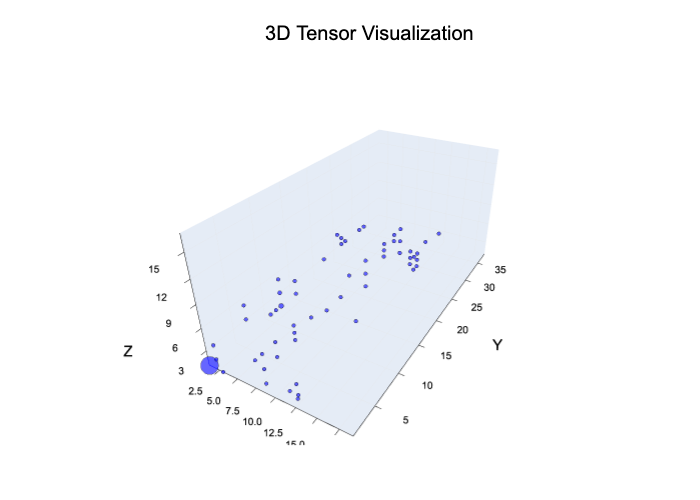

In [48]:
plot_tensor(T)

In [51]:
T_nd, Ys = nondeg(T)

(Δ = ITensor ord=3
Dim 1: (dim=15|id=679|"Vitamins,nondeg")
Dim 2: (dim=5|id=469|"Macronutrients,nondeg")
Dim 3: (dim=5|id=436|"Minerals,nondeg")
NDTensors.Dense{Float64, Vector{Float64}}
 15×5×5
[:, :, 1] =
 -311494.47316664597         …  -0.1427302503344251
     291.38824849733226          0.4054637491630905
     -26.07461678552097          0.007912918998498818
   -1600.4005837333932           0.0032488724239614353
     -75.66707071488379          0.03694586113157173
     -31.304250397798913     …   0.30681364785618315
   24070.1087311912              0.026849112523793208
      38.20718752013631          0.12986083918371719
     -20.513072062551487        -0.42154907247067547
   -4539.543366994005            8.576280870410094e-7
    2358.334382257404        …   0.15086122085090706
    2333.4461722279507          -0.17594058566005946
  -28454.09997875115             1.571880166835842
      -0.18461367029123732      -0.006861545042246919
       0.009637148056672809      0.0009745542082

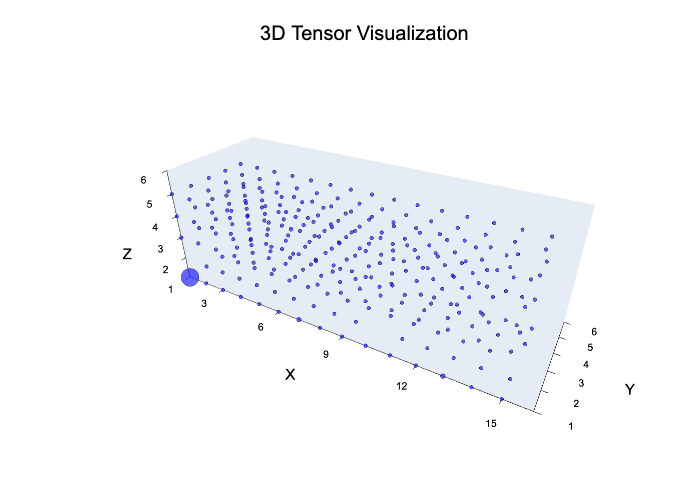

In [52]:
plot_tensor(T_nd)

In [53]:
S_nd, Ys = stratify(T_nd);

┌ Info: Found 10 derivations for stratification.
└ @ Dleto /Users/algeboy/CODE/OpenDleto/src/Densors.jl:44


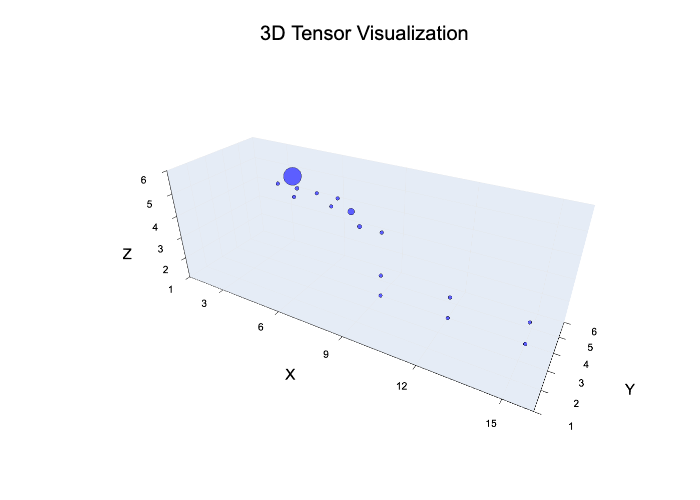

In [54]:
plot_tensor(S_nd)

In [18]:
# Visualize some tensor statistics
T_array = Array(T, idx_vitamins, idx_sugars, idx_fatty_acids)

println("Tensor Statistics:")
println("  Shape: ", size(T_array))
println("  Total sum: ", sum(T_array))
println("  Max value: ", maximum(T_array))
println("  Min value: ", minimum(T_array))
println("  Mean value: ", mean(T_array))
println("  Non-zero entries: ", count(x -> x != 0, T_array))

# Show some example slices
println("\nExample: Vitamin slice 1, Sugar slice 1:")
println(T_array[1, 1, 1:min(10, size(T_array, 3))])

Tensor Statistics:
  Shape: (37, 9, 87)
  Total sum: 473727.4347615418
  Max value: 339530.5420842473
  Min value: 0.0
  Mean value: 16.351780565446198
  Non-zero entries: 88

Example: Vitamin slice 1, Sugar slice 1:
[339530.5420842473, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [19]:
# The tensor T is now ready!
# It has:
# - Dimension 1 (Vitamins): 37 vitamin types
# - Dimension 2 (Sugars): 9 sugar types  
# - Dimension 3 (Fatty Acids): 87 fatty acid types
# - Values: L2 norm of macronutrient vectors for foods with that nutrient profile

println("Tensor T is ready for analysis!")
println("Access elements: T[idx_vitamins=>i, idx_sugars=>j, idx_fatty_acids=>k]")

Tensor T is ready for analysis!
Access elements: T[idx_vitamins=>i, idx_sugars=>j, idx_fatty_acids=>k]


In [21]:
using Dleto 


In [22]:

@time S, Xs = stratify(T)

Using SVDSolver...
Converting LinearMap to Matrix for SVD...


Using SVDSolver...
Converting LinearMap to Matrix for SVD...


┌ Info: Found 10 derivations for stratification.
└ @ Dleto /Users/algeboy/CODE/OpenDleto/src/Densors.jl:44


Using SVDSolver...
Converting LinearMap to Matrix for SVD...


┌ Info: Found 10 derivations for stratification.
└ @ Dleto /Users/algeboy/CODE/OpenDleto/src/Densors.jl:44


125.565438 seconds (380.57 M allocations: 45.897 GiB, 1.20% gc time, 4.93% compilation time: <1% of which was recompilation)


(Σ = ITensor ord=3
Dim 1: (dim=37|id=645|"(dim=37|id=582|",Site:Der")
Dim 2: (dim=9|id=570|"(dim=9|id=515|"S,Site:Der")
Dim 3: (dim=87|id=230|"(dim=87|id=17|"F,Site:Der")
NDTensors.Dense{Float64, Vector{Float64}}
 37×9×87
[:, :, 1] =
  1.9824698966903735e-20   1.0558644238971643e-21  …   1.2452201737406077e-28
  5.587418644341022e-21    3.3934631203749696e-22      2.342001127373864e-29
  4.353854415641111e-20    2.314671836927449e-21       2.706184370193626e-28
  7.842576115173194e-20    4.122599125784707e-21       5.081172736936421e-28
 -3.0302190179964034e-20  -1.562307417420635e-21      -2.104947183348643e-28
  1.030797048417688e-19    5.429207298521037e-21   …   6.606753265427883e-28
  9.183437646952246e-20    4.9734991466278045e-21      5.627941664529035e-28
  2.4393665024219293e-20   1.235834169169067e-21       1.8599213570261805e-28
 -1.5119657620674695e-19  -7.992465638060666e-21      -9.666055991722555e-28
 -2.124812166110336e-16   -1.3588557546816893e-17      7.79963751833889

In [24]:
using Plots

Loading Dleto Plots Extension


In [26]:

p1 = plot_tensor(T)
p2 = plot_tensor(S)
compare(p1, p2 )

Left 
 Plot{Plots.PlotlyJSBackend() n=2} 
 
 
 Right 
 Plot{Plots.PlotlyJSBackend() n=2}

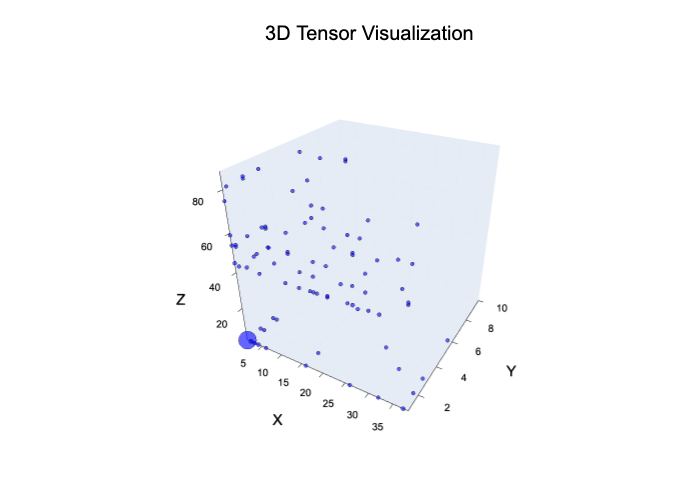

In [27]:
plot_tensor(T)

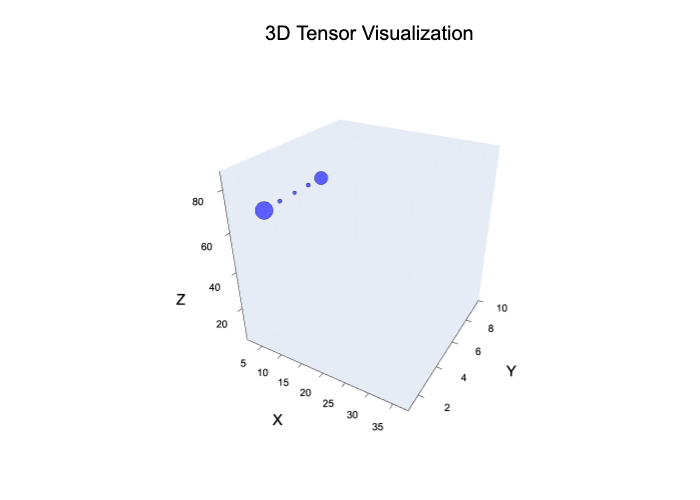

In [35]:
plot_tensor(S, 0.0001)

In [37]:
T_nd, Xs = nondeg(T, mode=:trunc)

(Δ = ITensor ord=3
Dim 1: (dim=10|id=775|"Fatty_Acids,nondeg")
Dim 2: (dim=17|id=439|"Vitamins,nondeg")
Dim 3: (dim=7|id=700|"Sugars,nondeg")
NDTensors.Dense{Float64, Vector{Float64}}
 10×17×7
[:, :, 1] =
 -338969.905830094             …  -8.676809461978864e-11
      -4.6241387937354116e-14     -3.455883089617806e-17
      -1.5089641484031824e-14     -1.1441647762834095e-17
      -6.57874648999773e-15       -4.944498384859764e-18
      -9.211040959142866e-15      -6.819485319899652e-18
      -3.781909361581583e-16   …  -3.027747084657321e-19
       1.290166521226914e-15       9.062384777843017e-19
       6.265934201182908e-15       4.75401301130907e-18
       2.8954249848828304e-15      2.143207487043215e-18
       2.2198287005408433e-15      1.6500363624906937e-18

[:, :, 2] =
 -2596.0304104457427         …  -2.941145116257434e-13
    -1.1109025485183812e-17      6.6194581662629496e-18
     5.916777249271513e-17       2.1915529766367428e-18
     9.054137757020024e-18       9.470777616

In [39]:
S_nd, Ys = stratify(T_nd, tol=1e-4);

┌ Info: Found 10 derivations for stratification.
└ @ Dleto /Users/algeboy/CODE/OpenDleto/src/Densors.jl:44


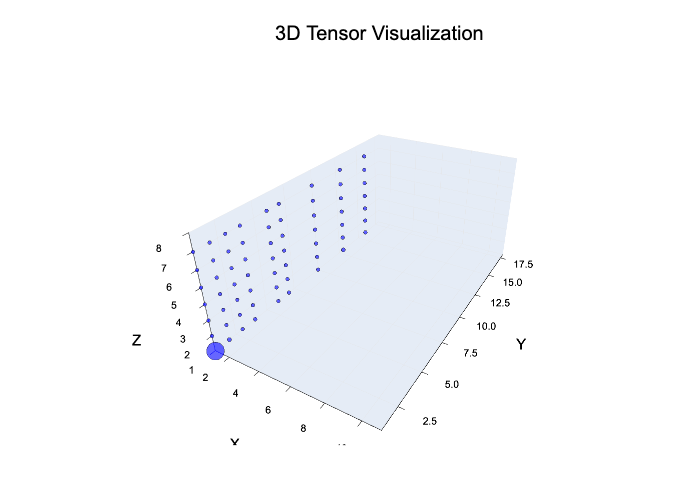

In [41]:
plot_tensor(T_nd, 0.0001)

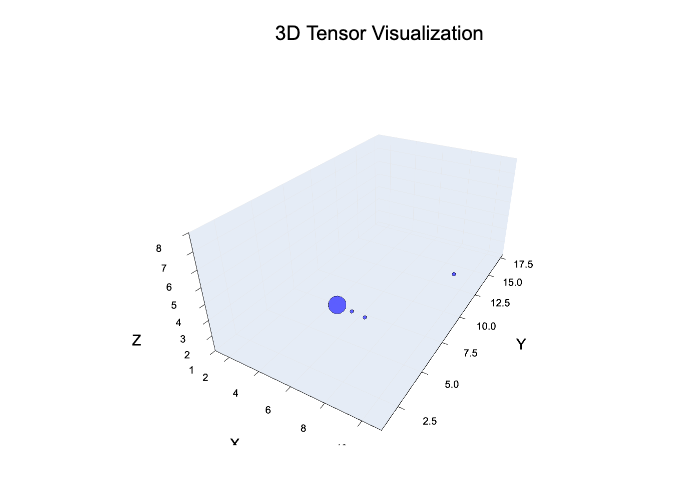

In [34]:
plot_tensor(S_nd)